# 4. Working with GridImage: Grid-Specific Features

This tutorial focuses on `GridImage` - a specialized class for analyzing arrayed microbe colonies on agar plates. GridImage extends the `Image` class with grid tracking and position-aware analysis.

**Prerequisites:** Complete the {doc}`Image` tutorial to understand core features.

## When to Use GridImage

✅ **Use GridImage** for: 96-well plates, 384-well plates, arrayed formats

❌ **Use regular Image** for: Single colonies, random arrangements

## Setup: Import Libraries

First, let's import the phenotypic library (commonly abbreviated as `pht`).


In [1]:
import phenotypic as pht
import numpy as np
import matplotlib.pyplot as plt


## Grid Components

GridImage adds grid-specific functionality:

1. **`grid_finder`**: Determines grid line placement (default: `AutoGridFinder`)
2. **`grid`**: Accessor for grid operations and visualization
3. **`nrows`, `ncols`**: Customizable grid dimensions
4. **`plot.overlay()`**: Visualization with gridlines and labels

(<Figure size 800x600 with 1 Axes>, <Axes: >)

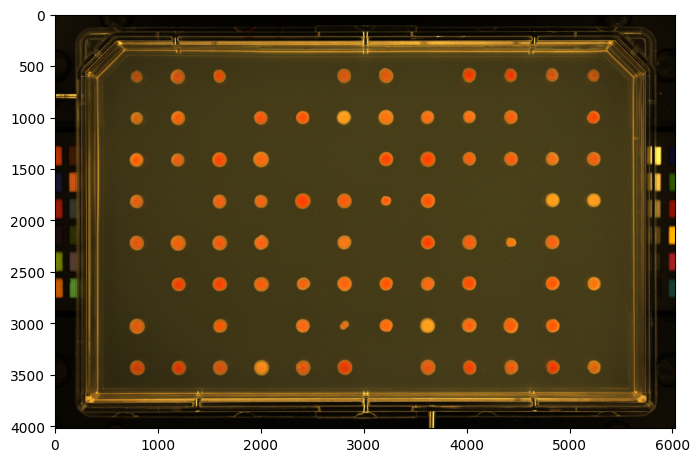

In [2]:
image = pht.data.load_imager_plate(mode="GridImage")
image.name = "MyGridImage"
image.show()


Cropped type: <class 'phenotypic.core._image.Image'>
Converted back: <class 'phenotypic.core._grid_image.GridImage'>


(<Figure size 800x600 with 1 Axes>, <Axes: >)

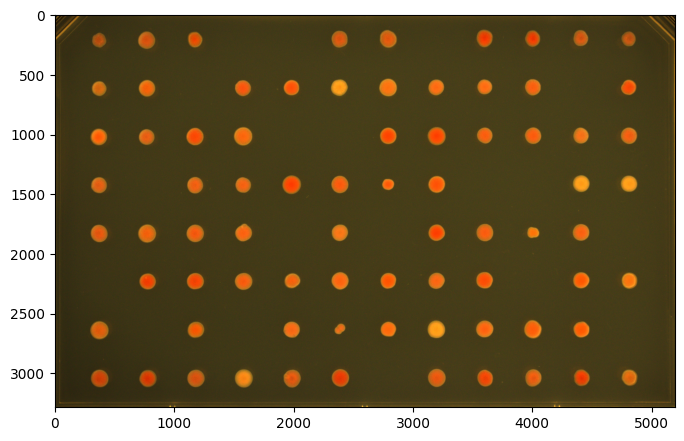

In [3]:
image = image[390:3675, 425:5620]  # Cropping a GridImage returns a regular Image
print(f"Cropped type: {type(image)}")

image = pht.GridImage(image)
print(f"Converted back: {type(image)}")

image.show()


In [4]:
# Examine grid properties
print(f"Grid finder type: {type(image.grid_finder).__name__}")
print(f"Number of rows: {image.nrows}")
print(f"Number of columns: {image.ncols}")
print(f"Total sections: {image.nrows*image.ncols}")


Grid finder type: AutoGridFinder
Number of rows: 8
Number of columns: 12
Total sections: 96


In [ ]:
pht.detect.RoundPeaksDetector().apply(image, inplace=True)

# The S&P imager uses plates that have a corner cutthing through the image, so we remove it with BorderObjectRemover
pht.refine.BorderObjectRemover(100).apply(image, inplace=True)
image.plot.overlay()


Notice how:
- **Cyan dashed lines** show the grid boundaries
- **Column numbers** appear at the top (0-11)
- **Row numbers** appear on the right (0-7)
- **Colored boxes** show which colonies belong to which grid section


## Part 3: Accessing Grid Information

After detection, the grid is automatically aligned to the colonies. We can access detailed grid assignment information using `grid.info()`.


In [6]:

# Get grid information for all colonies
grid_info = image.grid.info(include_metadata=True)

# Display first 10 colonies
print("Grid Information for Detected Colonies:")
print()
grid_info.head(10)


Grid Information for Detected Colonies:



,Metadata_BitDepth,Metadata_ImageType,Metadata_ImageName,ObjectLabel,Bbox_CenterRR,Bbox_CenterCC,Bbox_MinRR,Bbox_MinCC,Bbox_MaxRR,Bbox_MaxCC,Grid_RowNum,Grid_ColNum,Grid_SectionNum
0,16,GridImage,bedb3885-9588-4c86-8f8d-3f04b715cc4c,1,203.223483,3599.114734,133,3534,277,3666,0,8,8
1,16,GridImage,bedb3885-9588-4c86-8f8d-3f04b715cc4c,2,208.305812,2791.626799,134,2722,283,2865,0,6,6
2,16,GridImage,bedb3885-9588-4c86-8f8d-3f04b715cc4c,3,201.547514,4404.335588,135,4345,266,4467,0,10,10
3,16,GridImage,bedb3885-9588-4c86-8f8d-3f04b715cc4c,4,205.583136,4001.737503,138,3941,274,4064,0,9,9
4,16,GridImage,bedb3885-9588-4c86-8f8d-3f04b715cc4c,5,209.897206,2384.582457,140,2318,280,2451,0,5,5
5,16,GridImage,bedb3885-9588-4c86-8f8d-3f04b715cc4c,6,219.215315,767.650918,147,698,291,838,0,1,1
6,16,GridImage,bedb3885-9588-4c86-8f8d-3f04b715cc4c,7,209.147074,4809.871436,148,4761,268,4863,0,11,11
7,16,GridImage,bedb3885-9588-4c86-8f8d-3f04b715cc4c,8,214.015541,1172.998471,152,1117,279,1234,0,2,2
8,16,GridImage,bedb3885-9588-4c86-8f8d-3f04b715cc4c,9,223.262739,367.155403,161,314,279,424,0,0,0
9,16,GridImage,bedb3885-9588-4c86-8f8d-3f04b715cc4c,10,614.416882,2791.059955,539,2716,689,2866,1,6,18


### Understanding Grid Columns

Key columns:

- **`Grid_RowNum`, `Grid_ColNum`, `Grid_SectionNum`**: Grid position
- **`Bbox_Center/Min/Max*`**: Colony bounding box coordinates
- **`Metadata_*`**: Image name and type

In [7]:
# Example: Find all colonies in row 3
row_3_colonies = grid_info[grid_info['Grid_RowNum'] == 3]
print(f"Colonies in row 3: {len(row_3_colonies)}")
print()
row_3_colonies[['Grid_RowNum', 'Grid_ColNum', 'Grid_SectionNum']]


Colonies in row 3: 9



,Grid_RowNum,Grid_ColNum,Grid_SectionNum
29,3,10,46
30,3,4,40
31,3,11,47
32,3,5,41
33,3,7,43
34,3,2,38
35,3,0,36
36,3,3,39
37,3,6,42


In [8]:
# Example: Find colonies in a specific section (e.g., section 25)
section_25 = grid_info[grid_info['Grid_SectionNum'] == 25]
if len(section_25) > 0:
    print(
            f"Section 25 corresponds to row {section_25['Grid_RowNum'].iloc[0]}, column {section_25['Grid_ColNum'].iloc[0]}")
    print(f"Number of colonies detected: {len(section_25)}")
else:
    print("No colonies detected in section 25")


Section 25 corresponds to row 2, column 1
Number of colonies detected: 1


## Part 4: Working with Grid Sections

You can extract individual grid sections (wells) from the plate. Sections are numbered from 0 to (nrows × ncols - 1), going left-to-right, top-to-bottom.


In [9]:
# Access the first grid section (top-left)
section_0 = image.grid[0]

print(f"Section 0 shape: {section_0.shape}")
print(f"Number of objects in section 0: {section_0.num_objects}")


Section 0 shape: (404, 404, 3)
Number of objects in section 0: 0


In [ ]:
# Visualize a single section
fig, ax = section_0.plot.overlay()
plt.title("Grid Section 0 (Top-Left Well)")
plt.show()


## Advanced Grid Visualization

Access and visualize grid sections with specialized methods.

In [15]:
### Grid Section Access

Access individual wells by flat index or (row, col) tuple:

Row edges (pixel positions): [  10  414  819 1223 1628 2032 2436 2841 3245]

Column edges (pixel positions): [ 165  569  973 1377 1781 2185 2589 2993 3397 3801 4205 4609 5013]

Number of row edges: 9 (should be nrows + 1 = 9)
Number of column edges: 13 (should be ncols + 1 = 13)


In [17]:
# Analyze measurements by row
row_summary = measurements.groupby('Grid_RowNum')['Size_Area'].agg(
        ['mean', 'std', 'count'])
row_summary.columns = ['Mean Area', 'Std Area', 'Colony Count']

print("Colony Area Summary by Row:")
row_summary


Colony Area Summary by Row:



/var/folders/78/rnctrlmn5kj996kjnq_mmqlh0000gn/T/ipykernel_50922/1714487504.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  row_summary = measurements.groupby('Grid_RowNum')['Size_Area'].agg(['mean', 'std', 'count'])


,Mean Area,Std Area,Colony Count
Grid_RowNum,,,
0,12977.333333,2727.086220,9
1,14087.800000,1777.789251,10
2,15287.500000,1942.377652,10
3,14422.555556,3032.566574,9
4,15037.555556,2906.213822,9
5,14758.900000,1228.125894,10
6,14557.222222,3701.339311,9
7,13627.250000,4767.139911,12


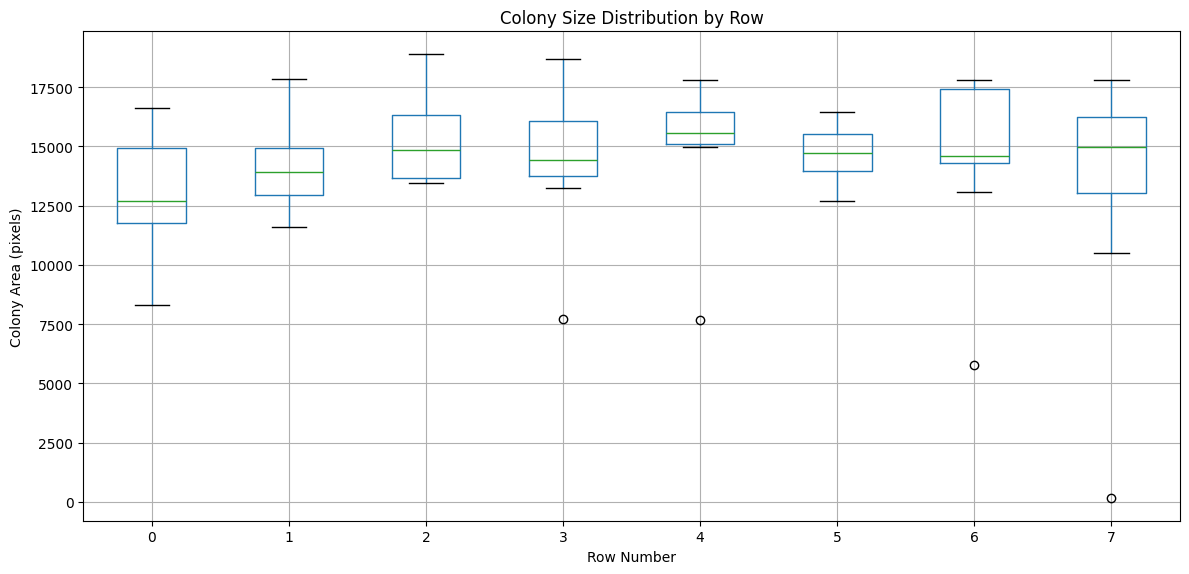

In [18]:
# Visualize area distribution by row
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
measurements.boxplot(column='Size_Area', by='Grid_RowNum', ax=plt.gca())
plt.xlabel('Row Number')
plt.ylabel('Colony Area (pixels)')
plt.title('Colony Size Distribution by Row')
plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.show()


### Exporting Data for Further Analysis

You can easily export measurements to CSV for analysis in other programs (Excel, R, etc.)

```python
measurements.to_csv("colony_measurements_with_grid.csv")
```

## Manual Grid Control (Advanced)

For custom grid placement, use `ManualGridFinder`:

```python
from phenotypic.grid import ManualGridFinder

row_edges = np.array([0, 410, 821, ...])  # 9 edges for 8 rows
col_edges = np.array([0, 432, 865, ...])  # 13 edges for 12 columns

finder = ManualGridFinder(row_edges=row_edges, col_edges=col_edges)
image = pht.GridImage(array, grid_finder=finder)
```

`AutoGridFinder` works well for most cases.

## Part 9: Alternative Loading Method

You can also load images directly from files using `GridImage.imread()`:

```python
# Example of loading from a file path:
image = pht.GridImage.imread('path/to/your/plate_image.jpg', nrows=8, ncols=12)

# You can also specify other parameters:
image = pht.GridImage.imread(
    'path/to/plate.jpg',
    name='my_experiment',
    nrows=16,  # For 384-well plate
    ncols=24
)


```
`GridImage.imread()` supports common formats: JPEG, PNG, TIFF


## Summary

### Key Takeaways

1. **GridImage = Image + Grid Support**: Inherits all Image features + grid tracking
2. **Automatic Grid Alignment**: Aligns to colonies using `AutoGridFinder`
3. **Position-Aware Measurements**: RowNum, ColNum, SectionNum automatically included
4. **Flexible Access**: Entire plate, grid sections, or individual colonies

### Typical Workflow

```python
# Load → Enhance → Detect → Visualize → Measure → Export
image = pht.GridImage.imread('plate.jpg', nrows=8, ncols=12)
image = GaussianBlur(sigma=5).apply(image)
image = OtsuDetector().apply(image)
image.plot.overlay(show_gridlines=True)
measurements = MeasureSize().measure(image)
measurements.to_csv('results.csv')
```

## Additional Resources

- **Documentation**: Full API reference in the documentation
- **Other Examples**: Check the `examples/` folder for more notebooks
- **Help**: Open an issue on GitHub for questions or bug reports

Happy analyzing! 🔬